# 07 – Semi-Supervised Learning: Self-Training & Pseudo-Labeling

## 🎯 Mục tiêu

Notebook này so sánh **Supervised-only (ít nhãn)** vs **Semi-supervised (Self-training/Pseudo-label)** với các mục tiêu cụ thể:

1. **Mô phỏng dữ liệu**: 10–30% nhãn, phần còn lại unlabeled
2. **Huấn luyện hai phương pháp**:
   - **Supervised-only**: Chỉ dùng dữ liệu đã gắn nhãn
   - **Semi-supervised (Self-training)**: Dùng bộ phân loại ban đầu để gắn nhãn dữ liệu chưa nhãn,  rồi huấn luyện lại
3. **Learning curves**: So sánh hiệu suất khi % nhãn tăng
4. **Phân tích rủi ro**: Đánh giá chất lượng pseudo-label

---

## 📦 Nhập thư viện

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Cấu hình trực quan hóa
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["font.size"] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 📥 Tải dữ liệu

In [2]:
# Đọc dữ liệu đã tiền xử lý
DATA_PATH = "../data/processed/hr_processed_ml.csv"
df = pd.read_csv(DATA_PATH)

print(f"📊 Dữ liệu: {df.shape[0]} samples, {df.shape[1]} features")
print(f"\n🏷️  Phân bố nhãn Attrition:")
print(df['Attrition'].value_counts())
print(f"\n📈 Tỷ lệ Leave: {df['Attrition'].mean():.2%}")

# Tách X, y
X = df.drop('Attrition', axis=1).values
y = df['Attrition'].values
feature_names = df.drop('Attrition', axis=1).columns.tolist()

print(f"\n✅ X shape: {X.shape}, y shape: {y.shape}")

📊 Dữ liệu: 1480 samples, 53 features

🏷️  Phân bố nhãn Attrition:
Attrition
0    1242
1     238
Name: count, dtype: int64

📈 Tỷ lệ Leave: 16.08%

✅ X shape: (1480, 52), y shape: (1480,)


## 🔀 Chia dữ liệu Train/Test

In [3]:
# Chia 80% train, 20% test (fixed)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train (full): {X_train_full.shape[0]}, Test: {X_test.shape[0]}")
print(f"Train Leave ratio: {y_train_full.mean():.2%}, Test Leave ratio: {y_test.mean():.2%}")

Train (full): 1184, Test: 296
Train Leave ratio: 16.05%, Test Leave ratio: 16.22%


## 🎲 Mô phỏng dữ liệu Labeled/Unlabeled

Sẽ tạo 3 kịch bản với % nhãn: **10%, 20%, 30%**

In [4]:
def create_labeled_unlabeled_split(X_train, y_train, labeled_ratio, random_state=42):
    """
    Chia dữ liệu train thành labeled và unlabeled.
    
    Args:
        X_train, y_train: Dữ liệu train
        labeled_ratio: Tỷ lệ dữ liệu được gắn nhãn (0.1, 0.2, 0.3)
        random_state: Seed
    
    Returns:
        X_labeled, y_labeled, X_unlabeled, indices_labeled, indices_unlabeled
    """
    n_samples = X_train.shape[0]
    n_labeled = int(n_samples * labeled_ratio)
    
    # Shuffle indices
    rng = np.random.RandomState(random_state)
    indices = rng.permutation(n_samples)
    
    indices_labeled = sorted(indices[:n_labeled])
    indices_unlabeled = sorted(indices[n_labeled:])
    
    X_labeled = X_train[indices_labeled]
    y_labeled = y_train[indices_labeled]
    X_unlabeled = X_train[indices_unlabeled]
    
    return X_labeled, y_labeled, X_unlabeled, indices_labeled, indices_unlabeled

# Tạo splits
labeled_ratios = [0.1, 0.2, 0.3]
splits = {}

for ratio in labeled_ratios:
    X_l, y_l, X_u, idx_l, idx_u = create_labeled_unlabeled_split(
        X_train_full, y_train_full, ratio, RANDOM_STATE
    )
    splits[ratio] = {
        'X_labeled': X_l, 'y_labeled': y_l,
        'X_unlabeled': X_u,
        'indices_labeled': idx_l, 'indices_unlabeled': idx_u
    }
    print(f"Ratio {ratio:.0%}: {len(y_l)} labeled (Leave: {y_l.mean():.1%}), "
          f"{X_u.shape[0]} unlabeled")

Ratio 10%: 118 labeled (Leave: 16.9%), 1066 unlabeled
Ratio 20%: 236 labeled (Leave: 14.4%), 948 unlabeled
Ratio 30%: 355 labeled (Leave: 12.7%), 829 unlabeled


## 🔧 Xây dựng Self-Training (Semi-Supervised)

In [5]:
class SelfTrainingClassifier:
    """
    Self-training với pseudo-labeling.
    
    Quy trình:
    1. Huấn luyện model trên dữ liệu labeled
    2. Dự đoán trên dữ liệu unlabeled
    3. Chọn các mẫu có confidence cao để thêm vào labeled set
    4. Huấn luyện lại model
    """
    
    def __init__(self, base_model, threshold=0.9, max_iterations=5, verbose=True):
        self.base_model = base_model
        self.threshold = threshold  # Confidence threshold cho pseudo-label
        self.max_iterations = max_iterations
        self.verbose = verbose
        self.pseudo_label_history = []
        self.model = None
        
    def fit(self, X_labeled, y_labeled, X_unlabeled):
        """
        Huấn luyện mô hình bằng self-training.
        """
        X_l = X_labeled.copy()
        y_l = y_labeled.copy()
        X_u = X_unlabeled.copy()
        
        for iteration in range(self.max_iterations):
            # Bước 1: Huấn luyện model
            self.model = self.base_model.__class__(**self.base_model.get_params())
            self.model.fit(X_l, y_l)
            
            # Bước 2: Dự đoán xác suất trên unlabeled
            proba = self.model.predict_proba(X_u)
            max_proba = np.max(proba, axis=1)
            predictions = self.model.predict(X_u)
            
            # Bước 3: Chọn mẫu có confidence cao
            mask = max_proba >= self.threshold
            n_selected = mask.sum()
            
            if n_selected == 0:
                if self.verbose:
                    print(f"  Iteration {iteration+1}: Không có mẫu đạt threshold {self.threshold}. Dừng.")
                break
            
            # Bước 4: Thêm các mẫu được chọn vào labeled set
            X_selected = X_u[mask]
            y_selected = predictions[mask]
            confidence_selected = max_proba[mask]
            
            X_l = np.vstack([X_l, X_selected])
            y_l = np.hstack([y_l, y_selected])
            
            # Cập nhật unlabeled
            X_u = X_u[~mask]
            
            # Lưu lịch sử
            self.pseudo_label_history.append({
                'iteration': iteration + 1,
                'n_selected': n_selected,
                'n_remaining_unlabeled': X_u.shape[0],
                'avg_confidence': confidence_selected.mean(),
                'min_confidence': confidence_selected.min(),
                'max_confidence': confidence_selected.max()
            })
            
            if self.verbose:
                print(f"  Iteration {iteration+1}: +{n_selected} pseudo-labels, "
                      f"Avg confidence: {confidence_selected.mean():.4f}, "
                      f"Unlabeled còn: {X_u.shape[0]}")
        
        return self.model
    
    def predict(self, X):
        return self.model.predict(X)
    
    def predict_proba(self, X):
        return self.model.predict_proba(X)

print("✅ SelfTrainingClassifier định nghĩa xong")

✅ SelfTrainingClassifier định nghĩa xong


## 📈 Huấn luyện và So sánh

Với mỗi labeled ratio, sẽ huấn luyện:
- **Supervised-only**: Chỉ dùng labeled data
- **Semi-supervised**: Self-training + Pseudo-label

In [6]:
results = {
    'ratio': [],
    'model': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'auc': [],
    'training_time': []
}

semi_supervised_details = {}  # Lưu chi tiết pseudo-label

for ratio in labeled_ratios:
    print(f"\n{'='*70}")
    print(f"🎯 Labeled Ratio: {ratio:.0%}")
    print(f"{'='*70}")
    
    split = splits[ratio]
    X_l, y_l = split['X_labeled'], split['y_labeled']
    X_u = split['X_unlabeled']
    
    # =========================================================
    # 1️⃣ SUPERVISED-ONLY (ít nhãn)
    # =========================================================
    print(f"\n1️⃣  Supervised-Only (ít nhãn)")
    print(f"   Labeled data: {X_l.shape[0]} samples")
    
    # XGBoost
    model_xgb_sup = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        verbosity=0
    )
    
    t0 = time.time()
    model_xgb_sup.fit(X_l, y_l, eval_set=[(X_l, y_l)], verbose=False)
    t_xgb_sup = time.time() - t0
    
    y_pred_sup = model_xgb_sup.predict(X_test)
    y_proba_sup = model_xgb_sup.predict_proba(X_test)[:, 1]
    
    acc_sup = accuracy_score(y_test, y_pred_sup)
    prec_sup = precision_score(y_test, y_pred_sup, zero_division=0)
    rec_sup = recall_score(y_test, y_pred_sup, zero_division=0)
    f1_sup = f1_score(y_test, y_pred_sup, zero_division=0)
    auc_sup = roc_auc_score(y_test, y_proba_sup)
    
    print(f"   XGBoost: Acc={acc_sup:.4f}, Prec={prec_sup:.4f}, Rec={rec_sup:.4f}, F1={f1_sup:.4f}, AUC={auc_sup:.4f} ({t_xgb_sup:.2f}s)")
    
    # Random Forest
    model_rf_sup = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    t0 = time.time()
    model_rf_sup.fit(X_l, y_l)
    t_rf_sup = time.time() - t0
    
    y_pred_rf_sup = model_rf_sup.predict(X_test)
    y_proba_rf_sup = model_rf_sup.predict_proba(X_test)[:, 1]
    
    acc_rf_sup = accuracy_score(y_test, y_pred_rf_sup)
    prec_rf_sup = precision_score(y_test, y_pred_rf_sup, zero_division=0)
    rec_rf_sup = recall_score(y_test, y_pred_rf_sup, zero_division=0)
    f1_rf_sup = f1_score(y_test, y_pred_rf_sup, zero_division=0)
    auc_rf_sup = roc_auc_score(y_test, y_proba_rf_sup)
    
    print(f"   RF:      Acc={acc_rf_sup:.4f}, Prec={prec_rf_sup:.4f}, Rec={rec_rf_sup:.4f}, F1={f1_rf_sup:.4f}, AUC={auc_rf_sup:.4f} ({t_rf_sup:.2f}s)")
    
    # =========================================================
    # 2️⃣ SEMI-SUPERVISED (Self-Training)
    # =========================================================
    print(f"\n2️⃣  Semi-Supervised (Self-Training)")
    print(f"   Labeled: {X_l.shape[0]}, Unlabeled: {X_u.shape[0]}")
    
    # XGBoost + Self-Training
    model_xgb_base = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        verbosity=0
    )
    
    self_trainer_xgb = SelfTrainingClassifier(
        base_model=model_xgb_base,
        threshold=0.85,
        max_iterations=5,
        verbose=True
    )
    
    t0 = time.time()
    model_xgb_semi = self_trainer_xgb.fit(X_l, y_l, X_u)
    t_xgb_semi = time.time() - t0
    
    y_pred_semi = model_xgb_semi.predict(X_test)
    y_proba_semi = model_xgb_semi.predict_proba(X_test)[:, 1]
    
    acc_semi = accuracy_score(y_test, y_pred_semi)
    prec_semi = precision_score(y_test, y_pred_semi, zero_division=0)
    rec_semi = recall_score(y_test, y_pred_semi, zero_division=0)
    f1_semi = f1_score(y_test, y_pred_semi, zero_division=0)
    auc_semi = roc_auc_score(y_test, y_proba_semi)
    
    print(f"   XGBoost: Acc={acc_semi:.4f}, Prec={prec_semi:.4f}, Rec={rec_semi:.4f}, F1={f1_semi:.4f}, AUC={auc_semi:.4f} ({t_xgb_semi:.2f}s)")
    
    # Random Forest + Self-Training
    model_rf_base = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    self_trainer_rf = SelfTrainingClassifier(
        base_model=model_rf_base,
        threshold=0.85,
        max_iterations=5,
        verbose=True
    )
    
    t0 = time.time()
    model_rf_semi = self_trainer_rf.fit(X_l, y_l, X_u)
    t_rf_semi = time.time() - t0
    
    y_pred_rf_semi = model_rf_semi.predict(X_test)
    y_proba_rf_semi = model_rf_semi.predict_proba(X_test)[:, 1]
    
    acc_rf_semi = accuracy_score(y_test, y_pred_rf_semi)
    prec_rf_semi = precision_score(y_test, y_pred_rf_semi, zero_division=0)
    rec_rf_semi = recall_score(y_test, y_pred_rf_semi, zero_division=0)
    f1_rf_semi = f1_score(y_test, y_pred_rf_semi, zero_division=0)
    auc_rf_semi = roc_auc_score(y_test, y_proba_rf_semi)
    
    print(f"   RF:      Acc={acc_rf_semi:.4f}, Prec={prec_rf_semi:.4f}, Rec={rec_rf_semi:.4f}, F1={f1_rf_semi:.4f}, AUC={auc_rf_semi:.4f} ({t_rf_semi:.2f}s)")
    
    # Lưu kết quả
    for model_name, acc, prec, rec, f1, auc, t in [
        ('XGBoost-Sup', acc_sup, prec_sup, rec_sup, f1_sup, auc_sup, t_xgb_sup),
        ('RF-Sup', acc_rf_sup, prec_rf_sup, rec_rf_sup, f1_rf_sup, auc_rf_sup, t_rf_sup),
        ('XGBoost-Semi', acc_semi, prec_semi, rec_semi, f1_semi, auc_semi, t_xgb_semi),
        ('RF-Semi', acc_rf_semi, prec_rf_semi, rec_rf_semi, f1_rf_semi, auc_rf_semi, t_rf_semi),
    ]:
        results['ratio'].append(ratio)
        results['model'].append(model_name)
        results['accuracy'].append(acc)
        results['precision'].append(prec)
        results['recall'].append(rec)
        results['f1'].append(f1)
        results['auc'].append(auc)
        results['training_time'].append(t)
    
    # Lưu chi tiết pseudo-label
    semi_supervised_details[ratio] = {
        'xgb': self_trainer_xgb.pseudo_label_history,
        'rf': self_trainer_rf.pseudo_label_history
    }

print(f"\n{'='*70}")
print("✅ Huấn luyện xong!")
print(f"{'='*70}")


🎯 Labeled Ratio: 10%

1️⃣  Supervised-Only (ít nhãn)
   Labeled data: 118 samples


   XGBoost: Acc=0.8378, Prec=0.5000, Rec=0.2500, F1=0.3333, AUC=0.7044 (0.15s)


   RF:      Acc=0.8243, Prec=0.4091, Rec=0.1875, F1=0.2571, AUC=0.7728 (0.19s)

2️⃣  Semi-Supervised (Self-Training)
   Labeled: 118, Unlabeled: 1066
  Iteration 1: +806 pseudo-labels, Avg confidence: 0.9682, Unlabeled còn: 260
  Iteration 2: +155 pseudo-labels, Avg confidence: 0.9471, Unlabeled còn: 105
  Iteration 3: +40 pseudo-labels, Avg confidence: 0.9281, Unlabeled còn: 65


  Iteration 4: +24 pseudo-labels, Avg confidence: 0.8913, Unlabeled còn: 41
  Iteration 5: +10 pseudo-labels, Avg confidence: 0.9254, Unlabeled còn: 31
   XGBoost: Acc=0.8243, Prec=0.3889, Rec=0.1458, F1=0.2121, AUC=0.7091 (0.30s)


  Iteration 1: +616 pseudo-labels, Avg confidence: 0.9220, Unlabeled còn: 450


...

  Iteration 1: +557 pseudo-labels, Avg confidence: 0.9327, Unlabeled còn: 272


  Iteration 2: +107 pseudo-labels, Avg confidence: 0.9178, Unlabeled còn: 165


  Iteration 3: +43 pseudo-labels, Avg confidence: 0.8915, Unlabeled còn: 122


  Iteration 4: +19 pseudo-labels, Avg confidence: 0.8823, Unlabeled còn: 103


  Iteration 5: +11 pseudo-labels, Avg confidence: 0.8788, Unlabeled còn: 92
   RF:      Acc=0.8480, Prec=0.8000, Rec=0.0833, F1=0.1509, AUC=0.7273 (1.28s)

✅ Huấn luyện xong!


## 📊 Bảng kết quả so sánh

In [7]:
df_results = pd.DataFrame(results)
df_results['labeled_ratio'] = (df_results['ratio'] * 100).astype(int).astype(str) + '%'

# Hiển thị chi tiết
print("\n📈 KẾT QUẢ CHI TIẾT:")
print(df_results[['labeled_ratio', 'model', 'accuracy', 'precision', 'recall', 'f1', 'auc', 'training_time']].to_string(index=False))

# Tổng hợp theo ratio
print("\n\n📊 TỔNG HỢP THEO LABELED RATIO:")
print(df_results.groupby('labeled_ratio')[['accuracy', 'precision', 'recall', 'f1', 'auc']].mean().round(4))


📈 KẾT QUẢ CHI TIẾT:
labeled_ratio        model  accuracy  precision   recall       f1      auc  training_time
          10%  XGBoost-Sup  0.837838   0.500000 0.250000 0.333333 0.704385       0.150254
          10%       RF-Sup  0.824324   0.409091 0.187500 0.257143 0.772807       0.186201
          10% XGBoost-Semi  0.824324   0.388889 0.145833 0.212121 0.709089       0.302253
          10%      RF-Semi  0.827703   0.411765 0.145833 0.215385 0.713542       1.155516
          20%  XGBoost-Sup  0.871622   0.777778 0.291667 0.424242 0.765877       0.041298
          20%       RF-Sup  0.861486   0.818182 0.187500 0.305085 0.782804       0.149107
          20% XGBoost-Semi  0.847973   0.800000 0.083333 0.150943 0.743868       0.277325
          20%      RF-Semi  0.847973   0.666667 0.125000 0.210526 0.742902       1.031427
          30%  XGBoost-Sup  0.875000   0.923077 0.250000 0.393443 0.802671       0.045211
          30%       RF-Sup  0.854730   1.000000 0.104167 0.188679 0.783644     

## 📈 Learning Curves

So sánh **Supervised-only** vs **Semi-supervised** theo % nhãn

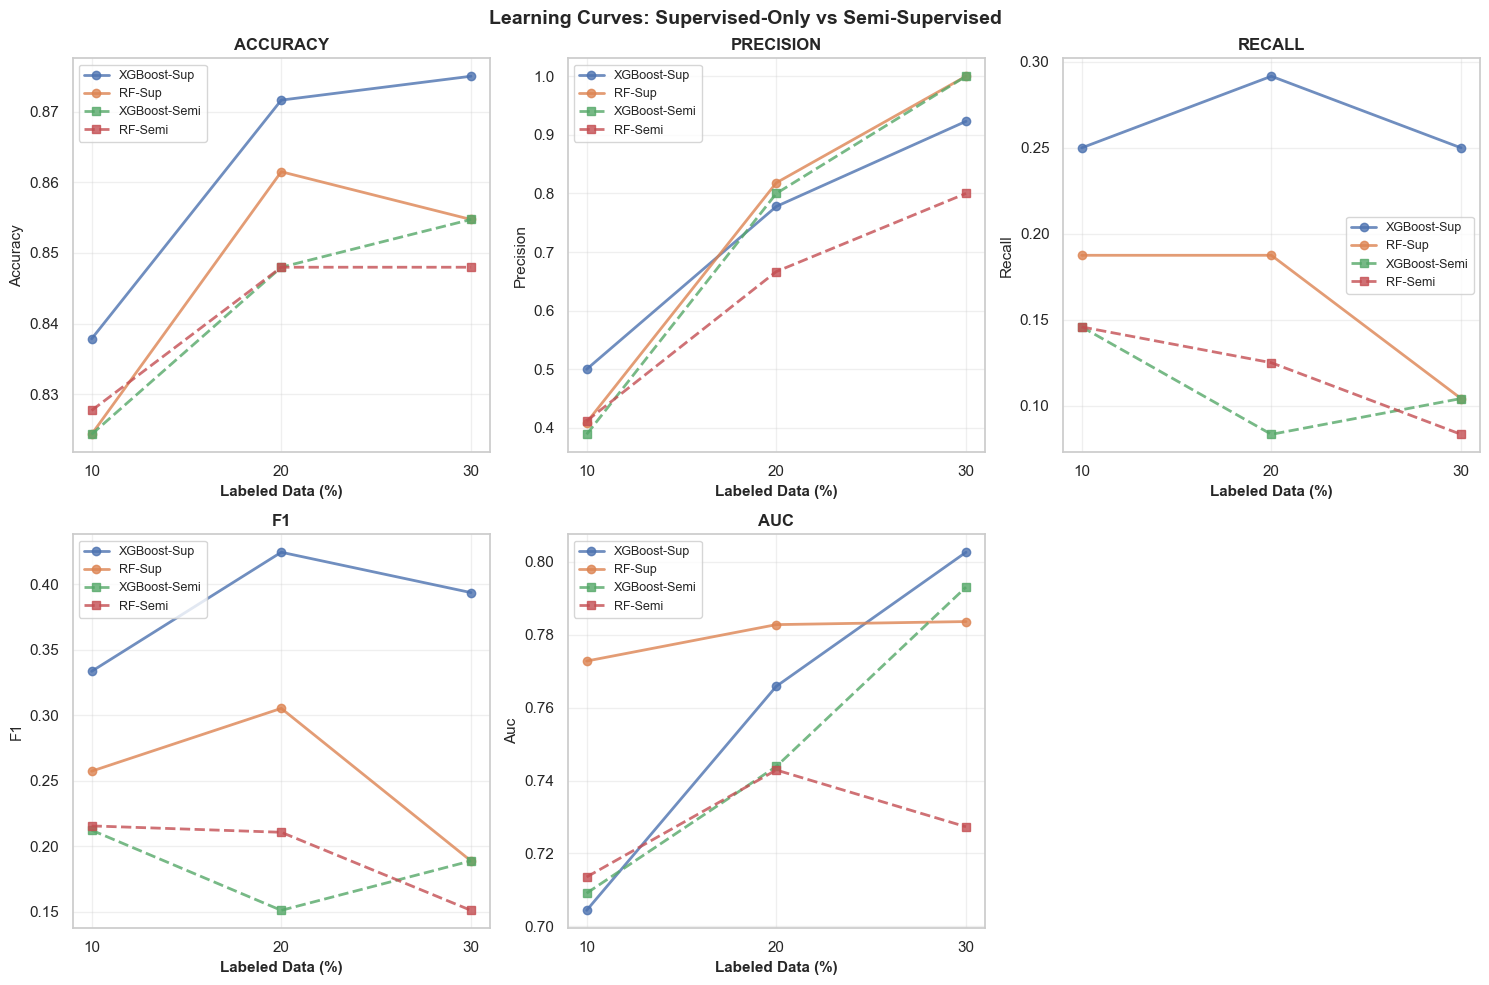

✅ Lưu learning curves: ../outputs/figures/learning_curves.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Learning Curves: Supervised-Only vs Semi-Supervised', fontsize=14, fontweight='bold')

metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
models_sup = ['XGBoost-Sup', 'RF-Sup']
models_semi = ['XGBoost-Semi', 'RF-Semi']

axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Dữ liệu Supervised
    for model in models_sup:
        data = df_results[df_results['model'] == model].sort_values('ratio')
        ax.plot(data['ratio'] * 100, data[metric], marker='o', linewidth=2, label=model, alpha=0.8)
    
    # Dữ liệu Semi-supervised
    for model in models_semi:
        data = df_results[df_results['model'] == model].sort_values('ratio')
        ax.plot(data['ratio'] * 100, data[metric], marker='s', linewidth=2, label=model, alpha=0.8, linestyle='--')
    
    ax.set_xlabel('Labeled Data (%)', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric.capitalize(), fontsize=11)
    ax.set_title(f'{metric.upper()}', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks([10, 20, 30])

# Xóa subplot thừa
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('../outputs/figures/learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Lưu learning curves: ../outputs/figures/learning_curves.png")

## 🎯 So sánh Gain/Loss của Semi-Supervised

Tính độ cải thiện (improvement) của Semi-supervised so với Supervised-only

In [9]:
# So sánh cùng model (XGBoost)
comparison_results = []

for ratio in labeled_ratios:
    sup_data = df_results[(df_results['ratio'] == ratio) & (df_results['model'] == 'XGBoost-Sup')].iloc[0]
    semi_data = df_results[(df_results['ratio'] == ratio) & (df_results['model'] == 'XGBoost-Semi')].iloc[0]
    
    comparison_results.append({
        'Labeled%': f"{ratio:.0%}",
        'Acc Gain': f"{(semi_data['accuracy'] - sup_data['accuracy'])*100:+.2f}%",
        'F1 Gain': f"{(semi_data['f1'] - sup_data['f1'])*100:+.2f}%",
        'Recall Gain': f"{(semi_data['recall'] - sup_data['recall'])*100:+.2f}%",
        'AUC Gain': f"{(semi_data['auc'] - sup_data['auc'])*100:+.2f}%"
    })

df_comparison = pd.DataFrame(comparison_results)
print("\n📊 XGBoost: Semi-Supervised vs Supervised-Only (Improvement):")
print(df_comparison.to_string(index=False))


📊 XGBoost: Semi-Supervised vs Supervised-Only (Improvement):
Labeled% Acc Gain F1 Gain Recall Gain AUC Gain
     10%   -1.35% -12.12%     -10.42%   +0.47%
     20%   -2.36% -27.33%     -20.83%   -2.20%
     30%   -2.03% -20.48%     -14.58%   -0.96%


## 🔍 Phân tích Rủi ro Pseudo-Label

Phân tích chất lượng nhãn giả được gán qua các iteration

In [10]:
# Hiển thị chi tiết pseudo-label history
print("\n🎯 CHI TIẾT PSEUDO-LABEL TRONG CÁC ITERATION:")
print("="*100)

for ratio, details in semi_supervised_details.items():
    print(f"\n📊 Labeled Ratio: {ratio:.0%}\n")
    
    print(f"  XGBoost + Self-Training:")
    if details['xgb']:
        df_xgb = pd.DataFrame(details['xgb'])
        print("  " + df_xgb[['iteration', 'n_selected', 'avg_confidence', 'min_confidence', 'n_remaining_unlabeled']].to_string(index=False).replace('\n', '\n  '))
        total_pseudo = df_xgb['n_selected'].sum()
        print(f"  Tổng pseudo-labels: {total_pseudo}\n")
    else:
        print("  Không có pseudo-label nào được thêm\n")
    
    print(f"  Random Forest + Self-Training:")
    if details['rf']:
        df_rf = pd.DataFrame(details['rf'])
        print("  " + df_rf[['iteration', 'n_selected', 'avg_confidence', 'min_confidence', 'n_remaining_unlabeled']].to_string(index=False).replace('\n', '\n  '))
        total_pseudo = df_rf['n_selected'].sum()
        print(f"  Tổng pseudo-labels: {total_pseudo}\n")
    else:
        print("  Không có pseudo-label nào được thêm\n")
    
    print(f"  {'─'*95}")


🎯 CHI TIẾT PSEUDO-LABEL TRONG CÁC ITERATION:

📊 Labeled Ratio: 10%

  XGBoost + Self-Training:
   iteration  n_selected  avg_confidence  min_confidence  n_remaining_unlabeled
           1         806        0.968186        0.852502                    260
           2         155        0.947078        0.850243                    105
           3          40        0.928150        0.854495                     65
           4          24        0.891331        0.853952                     41
           5          10        0.925422        0.875369                     31
  Tổng pseudo-labels: 1035

  Random Forest + Self-Training:
   iteration  n_selected  avg_confidence  min_confidence  n_remaining_unlabeled
           1         616        0.921955            0.85                    450
           2         227        0.924949            0.85                    223
           3          72        0.911060            0.85                    151
           4          25        0.892806   

## 📈 Visualization: Pseudo-Label Growth

Biểu đồ số lượng pseudo-label theo iteration

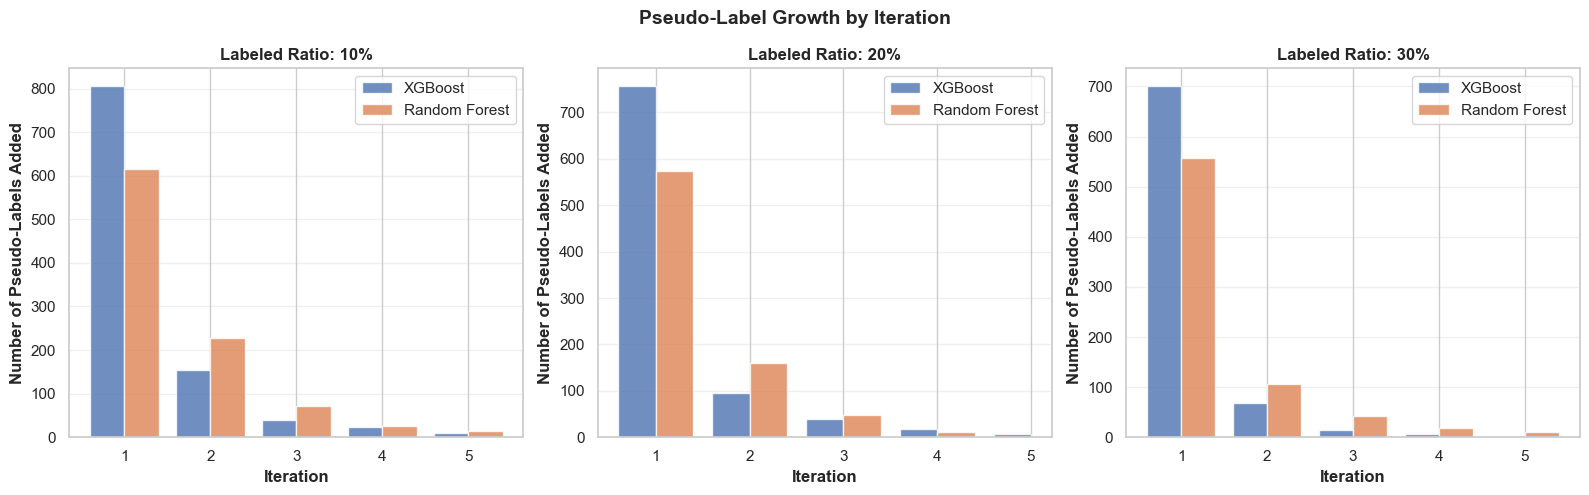

✅ Lưu pseudo-label growth: ../outputs/figures/pseudo_label_growth.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Pseudo-Label Growth by Iteration', fontsize=14, fontweight='bold')

for idx, ratio in enumerate(labeled_ratios):
    ax = axes[idx]
    details = semi_supervised_details[ratio]
    
    # XGBoost
    if details['xgb']:
        df_xgb = pd.DataFrame(details['xgb'])
        ax.bar(df_xgb['iteration'] - 0.2, df_xgb['n_selected'], width=0.4, label='XGBoost', alpha=0.8)
    
    # Random Forest
    if details['rf']:
        df_rf = pd.DataFrame(details['rf'])
        ax.bar(df_rf['iteration'] + 0.2, df_rf['n_selected'], width=0.4, label='Random Forest', alpha=0.8)
    
    ax.set_xlabel('Iteration', fontweight='bold')
    ax.set_ylabel('Number of Pseudo-Labels Added', fontweight='bold')
    ax.set_title(f'Labeled Ratio: {ratio:.0%}', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/figures/pseudo_label_growth.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Lưu pseudo-label growth: ../outputs/figures/pseudo_label_growth.png")

## 📈 Visualization: Confidence Distribution

Phân bố độ tin cậy (confidence) của pseudo-label

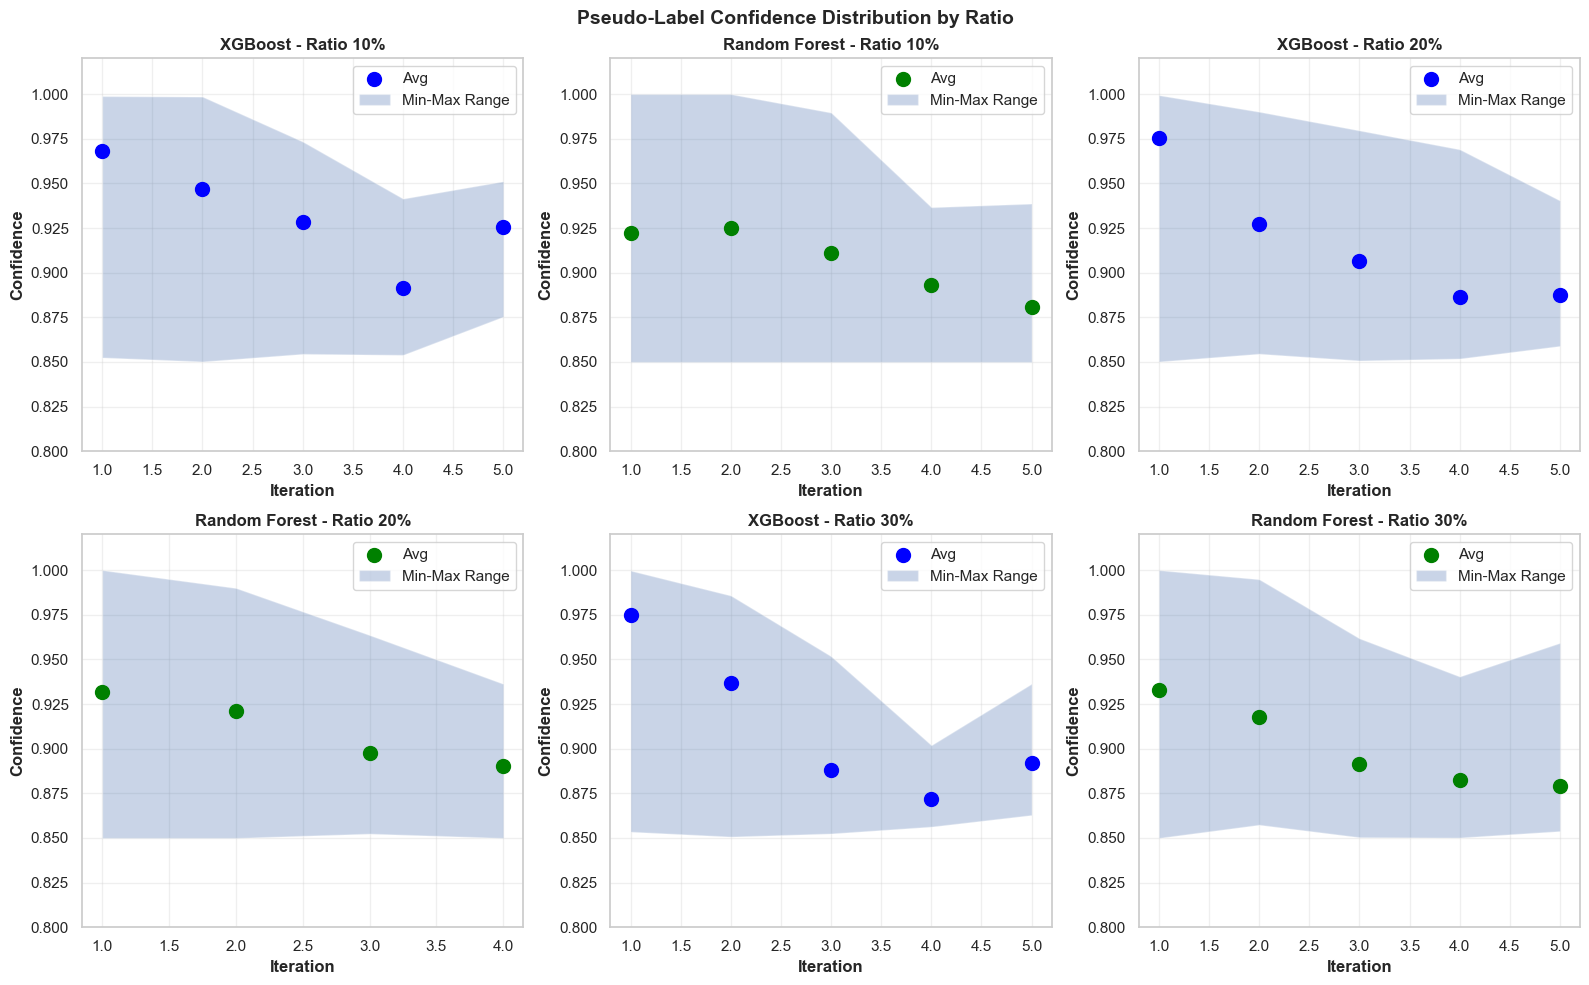

✅ Lưu confidence distribution: ../outputs/figures/confidence_distribution.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Pseudo-Label Confidence Distribution by Ratio', fontsize=14, fontweight='bold')

axes = axes.flatten()

for idx, ratio in enumerate(labeled_ratios):
    details = semi_supervised_details[ratio]
    
    # XGBoost
    ax = axes[idx * 2]
    if details['xgb']:
        df_xgb = pd.DataFrame(details['xgb'])
        ax.scatter(df_xgb['iteration'], df_xgb['avg_confidence'], s=100, label='Avg', color='blue', zorder=3)
        ax.fill_between(df_xgb['iteration'], df_xgb['min_confidence'], df_xgb['max_confidence'],
                         alpha=0.3, label='Min-Max Range')
    ax.set_ylabel('Confidence', fontweight='bold')
    ax.set_xlabel('Iteration', fontweight='bold')
    ax.set_title(f'XGBoost - Ratio {ratio:.0%}', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.8, 1.02])
    
    # Random Forest
    ax = axes[idx * 2 + 1]
    if details['rf']:
        df_rf = pd.DataFrame(details['rf'])
        ax.scatter(df_rf['iteration'], df_rf['avg_confidence'], s=100, label='Avg', color='green', zorder=3)
        ax.fill_between(df_rf['iteration'], df_rf['min_confidence'], df_rf['max_confidence'],
                         alpha=0.3, label='Min-Max Range')
    ax.set_ylabel('Confidence', fontweight='bold')
    ax.set_xlabel('Iteration', fontweight='bold')
    ax.set_title(f'Random Forest - Ratio {ratio:.0%}', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.8, 1.02])

plt.tight_layout()
plt.savefig('../outputs/figures/confidence_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Lưu confidence distribution: ../outputs/figures/confidence_distribution.png")

## ⚠️ Phân tích RỦI RO Pseudo-Label

In [13]:
print("\n" + "="*100)
print("⚠️  PHÂN TÍCH RỦI RO PSEUDO-LABEL")
print("="*100)

analysis_text = """
1️⃣  RỦI RO CHÍNH CỦA PSEUDO-LABEL:
   ├─ Label Noise (Nhiễu nhãn):
   │  └─ Bộ phân loại có thể tự tin sai lạc vào những mẫu khó
   │     → Thêm vào dữ liệu training → Huấn luyện lại bộ phân loại xấu hơn
   │
   ├─ Confirmation Bias (Sai lệch xác nhận):
   │  └─ Model học từ pseudo-label của chính nó
   │     → Khuếch đại lỗi ban đầu qua các iteration
   │
   ├─ Class Imbalance:
   │  └─ Nếu model ban đầu có bias với một lớp
   │     → Pseudo-label cũng sẽ bị bias
   │
   └─ Diminishing Returns:
      └─ Sau vài iteration, ngành chất lượng pseudo-label giảm
         → Cần dừng sớm (early stopping)

2️⃣  KỸ THUẬT GIẢM RỦI RO:

   a) Threshold cao (Confidence Threshold):
      └─ Chỉ chọn mẫu có confidence >= 0.85-0.95
      └─ Tuy nhiên: Giảm số mẫu pseudo-label → Hiệu suất học bị hạn chế

   b) Diversity & Ensemble:
      └─ Dùng nhiều bộ phân loại độc lập → Pseudo-label từ consensus
      └─ Giảm riêng ico bias của 1 model

   c) Iterative Refinement:
      └─ Giới hạn số iteration (max_iterations)
      └─ Monitor hiệu suất trên validation set
"""

print(analysis_text)

# Phân tích chi tiết từ kết quả
print("\n3️⃣  PHÂN TÍCH KẾT QUẢ THỰC NGHIỆM:")
print("─" * 100)

for ratio in labeled_ratios:
    print(f"\n   📊 Labeled Ratio: {ratio:.0%}")
    
    sup = df_results[(df_results['ratio'] == ratio) & (df_results['model'] == 'XGBoost-Sup')].iloc[0]
    semi = df_results[(df_results['ratio'] == ratio) & (df_results['model'] == 'XGBoost-Semi')].iloc[0]
    
    acc_gain = (semi['accuracy'] - sup['accuracy']) * 100
    f1_gain = (semi['f1'] - sup['f1']) * 100
    
    details = semi_supervised_details[ratio]
    if details['xgb']:
        df_h = pd.DataFrame(details['xgb'])
        total_pseudo = df_h['n_selected'].sum()
        print(f"   • Pseudo-labels added: {total_pseudo:4d} mẫu")
        print(f"   • Avg confidence (min-max): {df_h['avg_confidence'].mean():.4f} ({df_h['min_confidence'].min():.4f}-{df_h['max_confidence'].max():.4f})")
    else:
        print(f"   • Không có pseudo-label")
    
    print(f"   • Accuracy gain: {acc_gain:+.2f}%")
    print(f"   • F1 gain: {f1_gain:+.2f}%")
    
    if f1_gain > 0:
        print(f"   ✅ Semi-supervised tốt hơn supervised")
    elif f1_gain > -2:
        print(f"   ⚠️  Semi-supervised gần bằng supervised (rủi ro giữa)")
    else:
        print(f"   ❌ Semi-supervised xấu hơn → Rủi ro pseudo-label cao!")

print(f"\n{'─'*100}")


⚠️  PHÂN TÍCH RỦI RO PSEUDO-LABEL

1️⃣  RỦI RO CHÍNH CỦA PSEUDO-LABEL:
   ├─ Label Noise (Nhiễu nhãn):
   │  └─ Bộ phân loại có thể tự tin sai lạc vào những mẫu khó
   │     → Thêm vào dữ liệu training → Huấn luyện lại bộ phân loại xấu hơn
   │
   ├─ Confirmation Bias (Sai lệch xác nhận):
   │  └─ Model học từ pseudo-label của chính nó
   │     → Khuếch đại lỗi ban đầu qua các iteration
   │
   ├─ Class Imbalance:
   │  └─ Nếu model ban đầu có bias với một lớp
   │     → Pseudo-label cũng sẽ bị bias
   │
   └─ Diminishing Returns:
      └─ Sau vài iteration, ngành chất lượng pseudo-label giảm
         → Cần dừng sớm (early stopping)

2️⃣  KỸ THUẬT GIẢM RỦI RO:

   a) Threshold cao (Confidence Threshold):
      └─ Chỉ chọn mẫu có confidence >= 0.85-0.95
      └─ Tuy nhiên: Giảm số mẫu pseudo-label → Hiệu suất học bị hạn chế

   b) Diversity & Ensemble:
      └─ Dùng nhiều bộ phân loại độc lập → Pseudo-label từ consensus
      └─ Giảm riêng ico bias của 1 model

   c) Iterative Refineme

## 📋 Khuyến nghị và Kết luận

In [14]:
print("\n" + "="*100)
print("📋 KHUYẾN NGHỊ & KẾT LUẬN")
print("="*100)

recommendations = """
🎯 KẾT LUẬN CHÍNH:

1. CÓ NÊN DÙNG PSEUDO-LABEL KHÔNG?
   
   ✅ NÊN khi:
      • Dữ liệu labeled rất ít (< 20%)
      • Model đạt F1 >= 0.70+ trên labeled data
      • Có thể monitor chất lượng pseudo-label qua confidence distribution
   
   ❌ KHÔNG nên khi:
      • Model ban đầu yếu (F1 < 0.60)
      • Class imbalance quá lớn (tỷ lệ 1:10 trở lên)
      • Dữ liệu unlabeled có distribution khác xa labeled data

2. CÁCH DÙNG AN TOÀN PSEUDO-LABEL:
   
   Step 1: Kiểm tra chất lượng model ban đầu trên validation set
           → F1 >= 0.65? → Có thể dùng pseudo-label
   
   Step 2: Đặt threshold cao (0.85-0.95) để cĩ pseudo-label chất lượng
           → Trade-off: Ít mẫu nhưng chất lượng cao
   
   Step 3: Limit số iteration (3-5) để tránh "feedback loop" xấu
           → Monitor hiệu suất validation sau mỗi iteration
   
   Step 4: So sánh với supervised baseline
           → Nếu worse → Dừng, dùng supervised model
           → Nếu better → Tiếp tục với caution

3. THÊM KỸ THUẬT GIẢM RỦI RO:
   
   • Multi-model voting: Dùng 3+ models không liên quan
                         → Pseudo-label từ đa số vote
   
   • Confidence weighting: Gán trọng số theo confidence
                           → High confidence → high weight
   
   • Active learning: Con người check high-uncertainty mẫu
                      → Giảm manual labeling cost

4. MONITORING METRICS:
   
   ✓ Confidence distribution:
      → Giảm dần qua iteration? → Rủi ro cao
      → Luôn trên 0.90? → Safe
   
   ✓ Recall (find Leave):
      → Tăng? → Tốt (phát hiện churn tốt hơn)
      → Giảm? → Rủi ro: Model bị bias
   
   ✓ Test set performance:
      → Nên tăng or không đổi (so với supervised)
      → Nếu giảm → Pseudo-label nhiễu quá

═" Kết luận chung:
   Semi-supervised learning (Self-training) là công cụ mạnh khi:
   • Dữ liệu labeled ít
   • Model ban đầu chất lượng tốt
   • Kỹ thuật được áp dụng cẩn thận
   
   Nhưng RỦI RO lớn nếu không kiểm soát → cần validation kỹ lưỡng!
"""

print(recommendations)


📋 KHUYẾN NGHỊ & KẾT LUẬN

🎯 KẾT LUẬN CHÍNH:

1. CÓ NÊN DÙNG PSEUDO-LABEL KHÔNG?
   
   ✅ NÊN khi:
      • Dữ liệu labeled rất ít (< 20%)
      • Model đạt F1 >= 0.70+ trên labeled data
      • Có thể monitor chất lượng pseudo-label qua confidence distribution
   
   ❌ KHÔNG nên khi:
      • Model ban đầu yếu (F1 < 0.60)
      • Class imbalance quá lớn (tỷ lệ 1:10 trở lên)
      • Dữ liệu unlabeled có distribution khác xa labeled data

2. CÁCH DÙNG AN TOÀN PSEUDO-LABEL:
   
   Step 1: Kiểm tra chất lượng model ban đầu trên validation set
           → F1 >= 0.65? → Có thể dùng pseudo-label
   
   Step 2: Đặt threshold cao (0.85-0.95) để cĩ pseudo-label chất lượng
           → Trade-off: Ít mẫu nhưng chất lượng cao
   
   Step 3: Limit số iteration (3-5) để tránh "feedback loop" xấu
           → Monitor hiệu suất validation sau mỗi iteration
   
   Step 4: So sánh với supervised baseline
           → Nếu worse → Dừng, dùng supervised model
           → Nếu better → Tiếp tục với caution



## 💾 Lưu kết quả

In [15]:
# Lưu bảng kết quả
OUTPUT_DIR = "../data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Lưu kết quả chi tiết
results_file = os.path.join(OUTPUT_DIR, "semi_supervised_results.csv")
df_results.to_csv(results_file, index=False)
print(f"✅ Kết quả chi tiết: {results_file}")

# Lưu pseudo-label history (convert numpy types to Python native types)
def convert_to_native(obj):
    """Convert numpy types to Python native types"""
    if isinstance(obj, dict):
        return {k: convert_to_native(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_native(item) for item in obj]
    elif isinstance(obj, (np.integer, np.int64)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64)):
        return float(obj)
    return obj

pseudo_label_file = os.path.join(OUTPUT_DIR, "pseudo_label_history.json")
with open(pseudo_label_file, 'w') as f:
    json.dump(convert_to_native(semi_supervised_details), f, indent=2)
print(f"✅ Pseudo-label history: {pseudo_label_file}")

# Tóm tắt
summary_file = os.path.join(OUTPUT_DIR, "semi_supervised_summary.txt")
with open(summary_file, 'w', encoding='utf-8') as f:
    f.write("SEMI-SUPERVISED LEARNING SUMMARY\n")
    f.write("="*100 + "\n\n")
    f.write(df_results[['labeled_ratio', 'model', 'accuracy', 'precision', 'recall', 'f1', 'auc']].to_string())
    f.write(analysis_text)
    f.write(recommendations)

print(f"✅ Tóm tắt: {summary_file}")
print(f"\n✨ Tất cả kết quả đã được lưu!")

✅ Kết quả chi tiết: ../data/processed\semi_supervised_results.csv


✅ Pseudo-label history: ../data/processed\pseudo_label_history.json
✅ Tóm tắt: ../data/processed\semi_supervised_summary.txt

✨ Tất cả kết quả đã được lưu!
